In [9]:
# Install the package (uncomment if not already installed)
#!pip install git+https://github.com/sebastianprobst/resonator_tools.git

In [10]:
import numpy as np
import pandas as pd
from resonator_tools import circuit

In [11]:
# Replace the filename with your actual file path
file_path = 'Data/TWPA_on_S21_4.42-4.47GHz_-25.0dBm_20250605_205539.csv'
df = pd.read_csv(file_path)

# Convert units
freq = df['Frequency (GHz)'].values * 1e9
mag_lin = 10**(df['Magnitude (dB)'].values / 20)
phase_rad = np.deg2rad(df['Phase (deg)'].values)
s21_complex = mag_lin * np.exp(1j * phase_rad)

In [12]:
fit = circuit.notch_port()
fit.add_data(freq, s21_complex)

delay, a, alpha, fr, Ql, A2, frcal = fit.do_calibration(fit.f_data, fit.z_data_raw)
fit.z_data = fit.do_normalization(fit.f_data, fit.z_data_raw, delay, a, alpha, A2, frcal)
fit.fitresults = fit.circlefit(fit.f_data, fit.z_data, fr, Ql)

print(f"Ql = {fit.fitresults['Ql']:.2e}")
print(f"Qc = {fit.fitresults['Qc_dia_corr']:.2e}")
print(f"Qi = {fit.fitresults['Qi_dia_corr']:.2e}")

Ql = 1.31e+03
Qc = 1.88e+03
Qi = 4.29e+03


In [13]:
print(fit.fitresults.keys())
print(fit.fitresults['Qi_no_corr'])
print(fit.fitresults['Qi_dia_corr'])

dict_keys(['Qi_dia_corr', 'Qi_no_corr', 'absQc', 'Qc_dia_corr', 'Ql', 'fr', 'theta0', 'phi0', 'phi0_err', 'Ql_err', 'absQc_err', 'fr_err', 'chi_square', 'Qi_no_corr_err', 'Qi_dia_corr_err'])
4485.1855457462625
4292.975299226241


dict_keys(['Qi_dia_corr', 'Qi_no_corr', 'absQc', 'Qc_dia_corr', 'Ql', 'fr', 'theta0', 'phi0', 'phi0_err', 'Ql_err', 'absQc_err', 'fr_err', 'chi_square', 'Qi_no_corr_err', 'Qi_dia_corr_err'])
Ql            = 1.31e+03
Qc (absQc)    = 1.84e+03
Qc (dia corr) = 1.88e+03
Qi (no corr)  = 4.49e+03
Qi (dia corr) = 4.29e+03


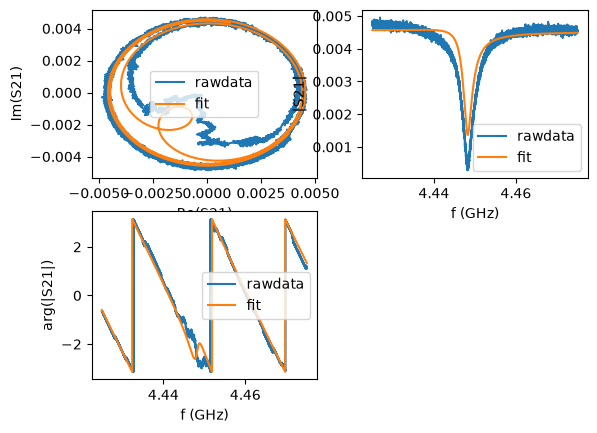

In [14]:
fit = circuit.notch_port()
fit.add_data(freq, s21_complex)

fit.autofit()

print(fit.fitresults.keys())
print(f"Ql            = {fit.fitresults['Ql']:.2e}")
print(f"Qc (absQc)    = {fit.fitresults['absQc']:.2e}")
print(f"Qc (dia corr) = {fit.fitresults['Qc_dia_corr']:.2e}")
print(f"Qi (no corr)  = {fit.fitresults['Qi_no_corr']:.2e}")
print(f"Qi (dia corr) = {fit.fitresults['Qi_dia_corr']:.2e}")

fit.plotall()